**Procesamiento de Imágenes   ITSE - Instituto Tecnológico de Santiago del Estero**


# Image Processing with Geometric Transformation

# Libraries

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Read the image

In [2]:
REPO = 'https://raw.githubusercontent.com/domingomery/pr/main/clases/'
!wget {REPO}PR01_Introduccion/datos/louvre.png

--2026-09-01 13:39:49--  https://raw.githubusercontent.com/domingomery/pr/main/clases/PR01_Introduccion/datos/louvre.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 790510 (772K) [image/png]
Saving to: ‘louvre.png’

louvre.png          100%[===================>] 771.98K  --.-KB/s    in 0.007s  

2026-09-01 13:39:50 (115 MB/s) - ‘louvre.png’ saved [790510/790510]



size =  (1024, 1024)


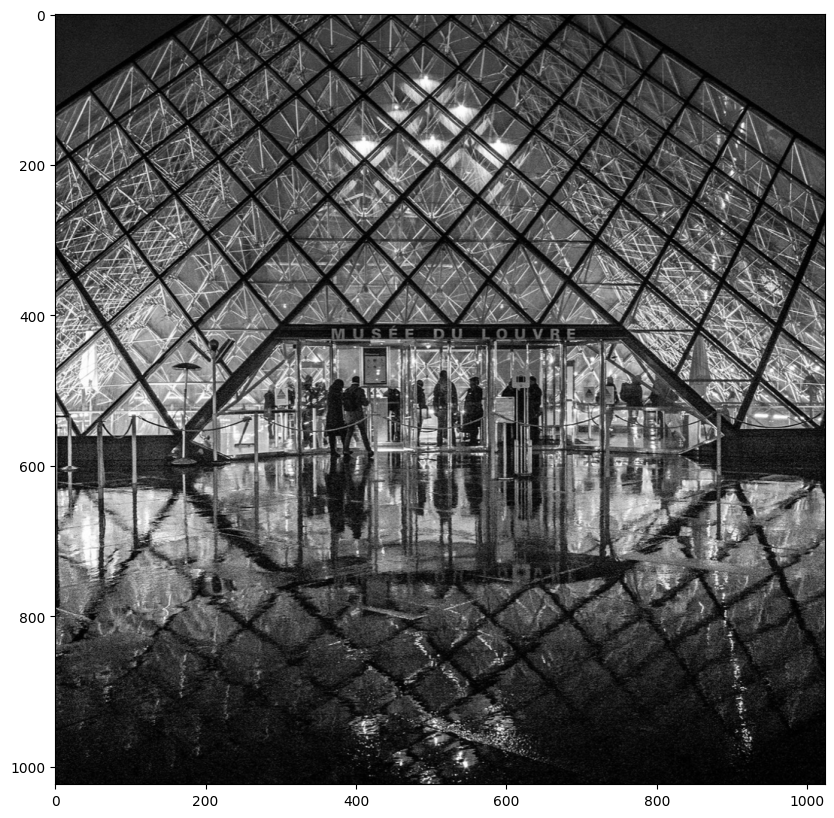

In [3]:
X = cv2.imread('louvre.png',0)
print('size = ',X.shape)
plt.figure(figsize=(10,10))
plt.imshow(X,cmap='gray')
plt.show()

# Geometric Transformation

Input coordinates ${\bf X}$: $(i_0,j_0)$

Output coordinates ${\bf Y}$: $(i,j)$



$i_0 = a_{11}i + a_{12}j+a_{13}$

$j_0 = a_{21}i + a_{22}j+a_{23}$

where ${\bf m} = [i \ j \ 1]^{\sf T}$ y ${\bf m}_0 = [i_0 \ j_0 ]^{\sf T}$.

Thus,

${\bf m}_0 = {\bf A}{\bf m}$

A --> 2x3 m --> 3x1  ----- m0 = A.m --> 2x1

In [4]:
# Interpolation using nearest integer towards zero
def geo_transformation(X,A,Yshape=None):

  if Yshape is None:
    (N,M) = X.shape
  else:
    (N,M) = Yshape
  Y = np.zeros((N,M),np.uint8)

  m = np.ones((N*M,3)) #1,1,1/1,2,1/1,3,1/        1024, 1024, 1 m
  t = 0
  for i in range(N):
    for j in range(M):
      m[t,0:3] = [i,j,1]
      t = t+1

  m0  = np.dot(A,m.T)          # (i,j) -> (i0,j0) using equation explained above
  mpf = np.fix(m0).astype(int) # nearest integer towards zero

  # verification: does the pixel (i0,j0) belong to the image?
  i0 = mpf[0,:]
  j0 = mpf[1,:]
  kti = np.logical_and(i0>=0,i0<N)
  ktj = np.logical_and(j0>=0,j0<M)
  kt  = np.logical_and(kti,ktj)

  # output image
  t = 0
  for i in range(N):
    for j in range(M):
      if kt[t]:
        Y[i,j] = X[i0[t],j0[t]]
      t = t+1
  return Y

# Translation

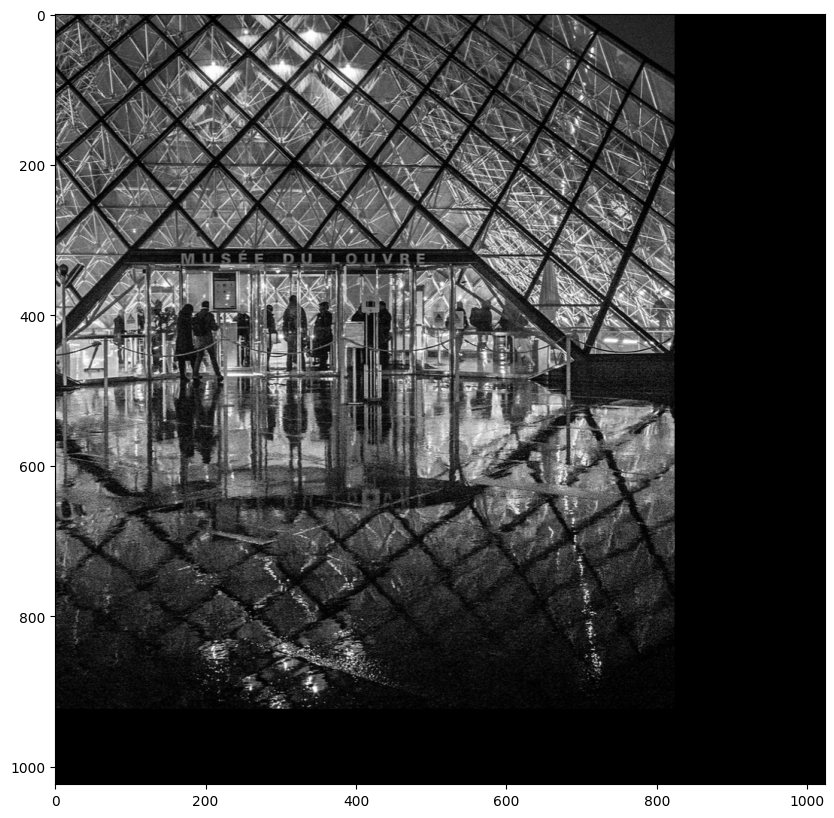

In [5]:
a11 = 1
a12 = 0
a13 = 100

a21 = 0
a22 = 1
a23 = 200

a1 = np.array([a11,a12,a13])
a2 = np.array([a21,a22,a23])

A  = np.vstack([a1,a2])

Y = geo_transformation(X,A)
plt.figure(figsize=(10,10))
plt.imshow(Y,cmap='gray')
plt.show()


# Rotation

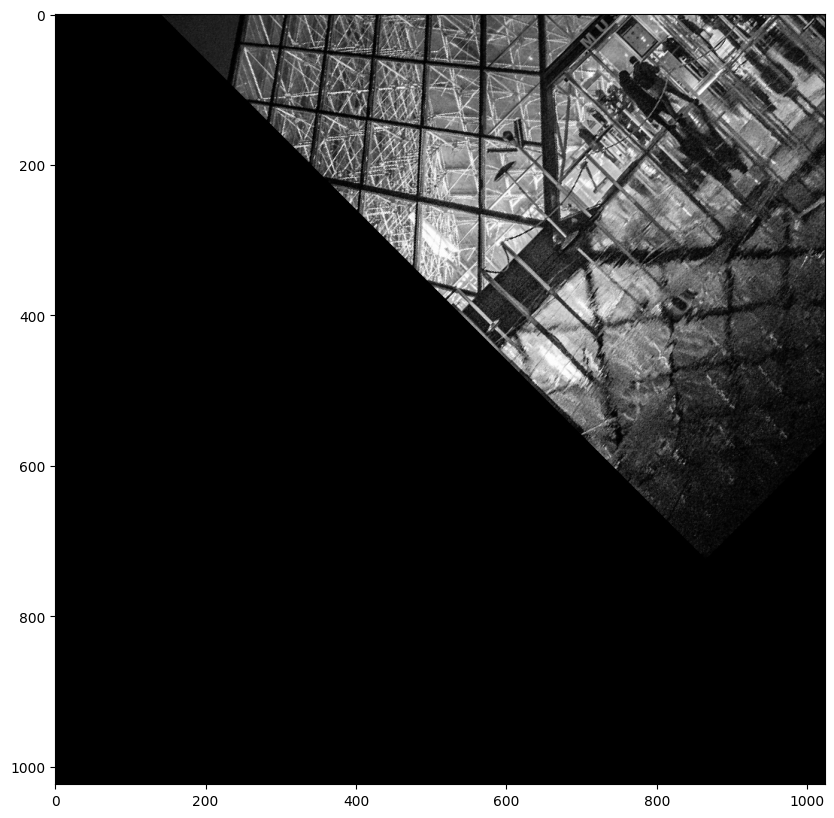

In [6]:
theta = 45.0 / 180.0 * np.pi #ponerlo en radianes
a11   = np.cos(theta)
a12   = np.sin(theta)
a13   = -100
a21   = -np.sin(theta)
a22   =  np.cos(theta)
a23   = -100
a1    = np.array([a11,a12,a13])
a2    = np.array([a21,a22,a23])
A     = np.vstack([a1,a2])
Y     = geo_transformation(X,A)
plt.figure(figsize=(10,10))
plt.imshow(Y,cmap='gray')
plt.show()

# Scaling

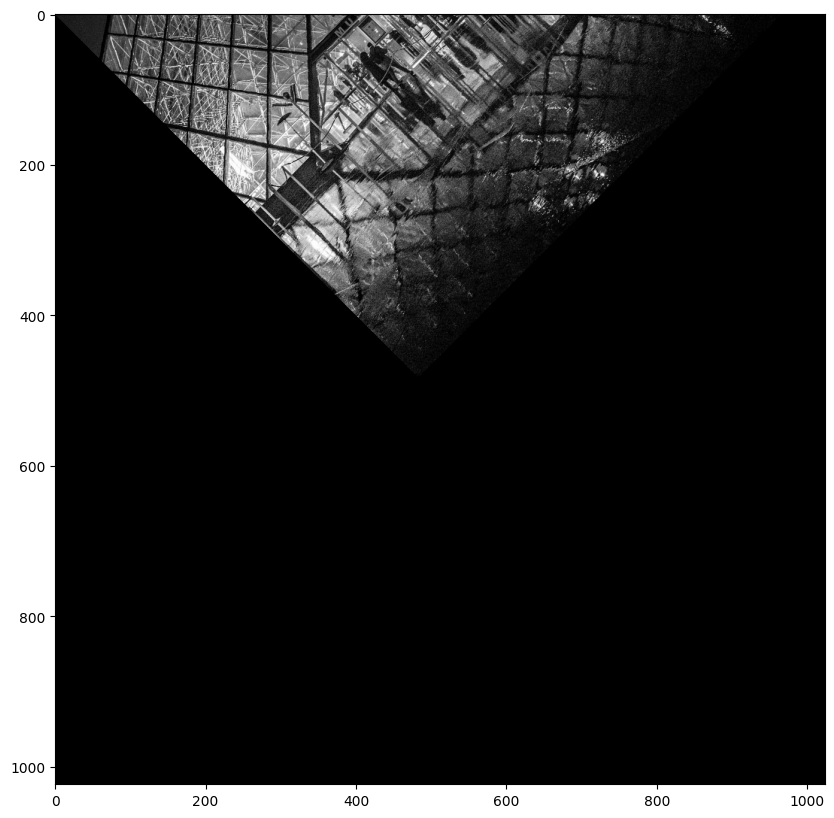

In [7]:
theta = 45.0 / 180.0 * np.pi

s     = 1.5


a11 = s*np.cos(theta)
a12 = s*np.sin(theta)
a13 = 0

a21 = -s*np.sin(theta)
a22 =  s*np.cos(theta)
a23 = 0

a1 = np.array([a11,a12,a13])
a2 = np.array([a21,a22,a23])

A  = np.vstack([a1,a2])

Y = geo_transformation(X,A)
plt.figure(figsize=(10,10))
plt.imshow(Y,cmap='gray')
plt.show()


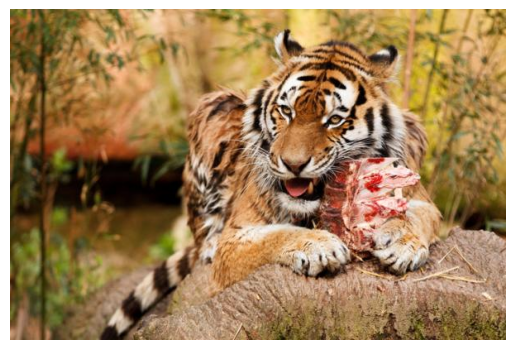

In [8]:
import requests
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# URL de la imagen
url = "https://cdn0.expertoanimal.com/es/posts/8/5/0/alimentacion_del_tigre_25058_1_600.jpg"

# Descargar la imagen
nombre_archivo = "tigre.jpg"
r = requests.get(url)
with open(nombre_archivo, "wb") as f:
    f.write(r.content)

# Mostrar la imagen
img = mpimg.imread(nombre_archivo)
plt.imshow(img)
plt.axis("off")
plt.show()

Transforma la imagen a escala de grises y realiza las actividades.
1. Realizar una traslación de la imagen: Desplazar la imagen 50 píxeles a la derecha y 30 píxeles hacia abajo. Mostrar el resultado.

2. Realizar una rotación de la imagen: Rotar 45° la imagen. Mostrar el resultado.

3. Realizar una combinación de transformaciones: Primero trasladar la imagen y luego rotarla. Mostrar el resultado.

4. Mostrar la imagen original y todas las transformadas en una misma figura para comparar.

## Procesamiento de `tigre.jpg`

In [9]:
import cv2

# Convertir la imagen 'tigre.jpg' a escala de grises
tigre_gray_img = cv2.imread('tigre.jpg', cv2.IMREAD_GRAYSCALE)

# Verificar si la imagen se cargó correctamente
if tigre_gray_img is None:
    print('Error: No se pudo cargar la imagen tigre.jpg')
else:
    print(f'Tamaño de la imagen en escala de grises: {tigre_gray_img.shape}')
    # Guardar el tamaño para cálculos posteriores
    N_tigre, M_tigre = tigre_gray_img.shape
    cx_tigre = M_tigre / 2.0
    cy_tigre = N_tigre / 2.0

Tamaño de la imagen en escala de grises: (400, 600)


### 1. Traslación de la imagen: 50 píxeles a la derecha y 30 píxeles hacia abajo

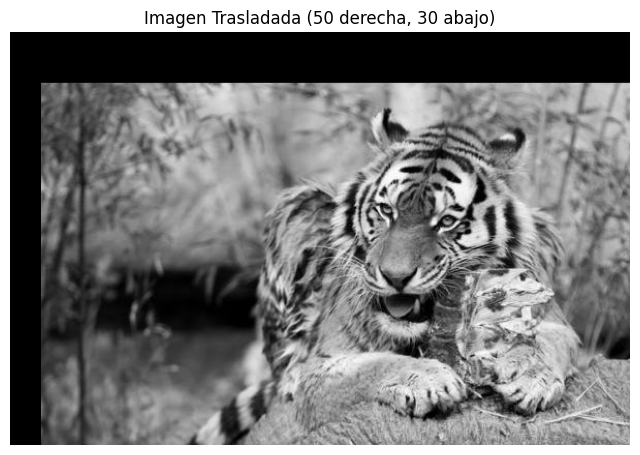

In [10]:
# Matriz de transformación para traslación
Tx = 50 # Desplazamiento a la derecha
Ty = 30 # Desplazamiento hacia abajo

A_translation_matrix = np.array([
    [1, 0, -Tx], # Para la traslación, los valores de a13 y a23 son negativos del desplazamiento
    [0, 1, -Ty]
])

Y_translated = geo_transformation(tigre_gray_img, A_translation_matrix)

plt.figure(figsize=(8, 8))
plt.imshow(Y_translated, cmap='gray')
plt.title('Imagen Trasladada (50 derecha, 30 abajo)')
plt.axis('off')
plt.show()

### 2. Rotación de la imagen: 45°

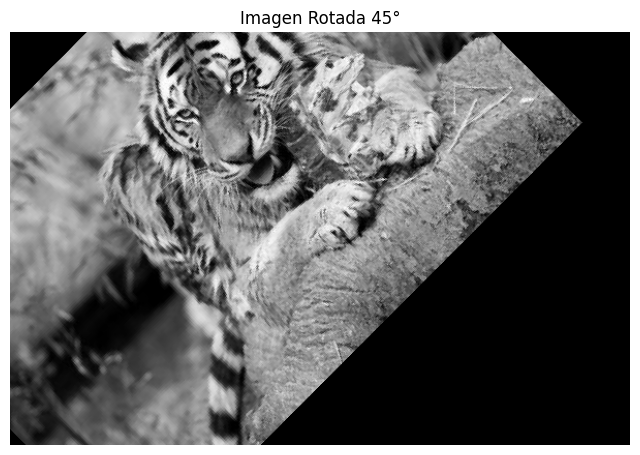

In [11]:
# Matriz de transformación para rotación de 45 grados alrededor del centro
theta_rotation = 45.0 / 180.0 * np.pi # Convertir a radianes

# Calcular los componentes de la matriz de rotación inversa para centrar la imagen
# i0 = (i - cx) * cos(theta) + (j - cy) * sin(theta) + cx
# j0 = -(i - cx) * sin(theta) + (j - cy) * cos(theta) + cy

a11_rot = np.cos(theta_rotation)
a12_rot = np.sin(theta_rotation)
a13_rot = cx_tigre - cx_tigre * np.cos(theta_rotation) - cy_tigre * np.sin(theta_rotation)

a21_rot = -np.sin(theta_rotation)
a22_rot = np.cos(theta_rotation)
a23_rot = cy_tigre + cx_tigre * np.sin(theta_rotation) - cy_tigre * np.cos(theta_rotation)

A_rotation_matrix = np.array([
    [a11_rot, a12_rot, a13_rot],
    [a21_rot, a22_rot, a23_rot]
])

Y_rotated = geo_transformation(tigre_gray_img, A_rotation_matrix)

plt.figure(figsize=(8, 8))
plt.imshow(Y_rotated, cmap='gray')
plt.title('Imagen Rotada 45°')
plt.axis('off')
plt.show()

### 3. Combinación de transformaciones: Primero traslación, luego rotación

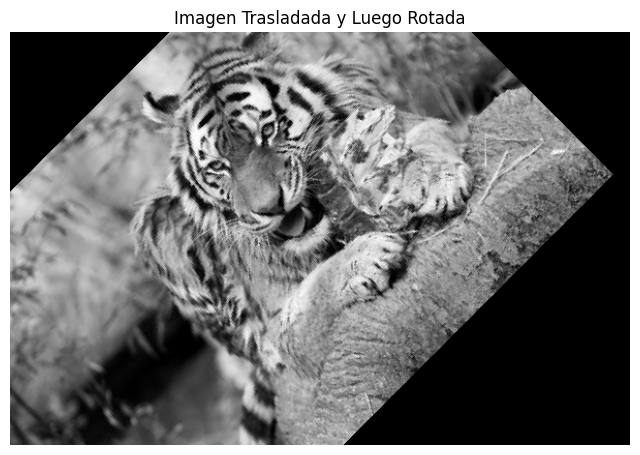

In [12]:
# La transformación combinada es T_inv @ R_inv (R_forward @ T_forward)^-1
# Donde R_forward es rotación alrededor del centro, y T_forward es traslación.
# Las ecuaciones para (i0, j0) en términos de (i, j) para la transformación inversa combinada son:
# i0 = (i - Tx - cx) * cos(theta) + (j - Ty - cy) * sin(theta) + cx
# j0 = -(i - Tx - cx) * sin(theta) + (j - Ty - cy) * cos(theta) + cy

# Utilizando los valores de Tx, Ty y theta_rotation definidos anteriormente

a11_comb = np.cos(theta_rotation)
a12_comb = np.sin(theta_rotation)
a13_comb = cx_tigre - (Tx + cx_tigre) * np.cos(theta_rotation) - (Ty + cy_tigre) * np.sin(theta_rotation)

a21_comb = -np.sin(theta_rotation)
a22_comb = np.cos(theta_rotation)
a23_comb = cy_tigre + (Tx + cx_tigre) * np.sin(theta_rotation) - (Ty + cy_tigre) * np.cos(theta_rotation)

A_combined_matrix = np.array([
    [a11_comb, a12_comb, a13_comb],
    [a21_comb, a22_comb, a23_comb]
])

Y_combined = geo_transformation(tigre_gray_img, A_combined_matrix)

plt.figure(figsize=(8, 8))
plt.imshow(Y_combined, cmap='gray')
plt.title('Imagen Trasladada y Luego Rotada')
plt.axis('off')
plt.show()

### 4. Mostrar la imagen original y todas las transformadas en una misma figura

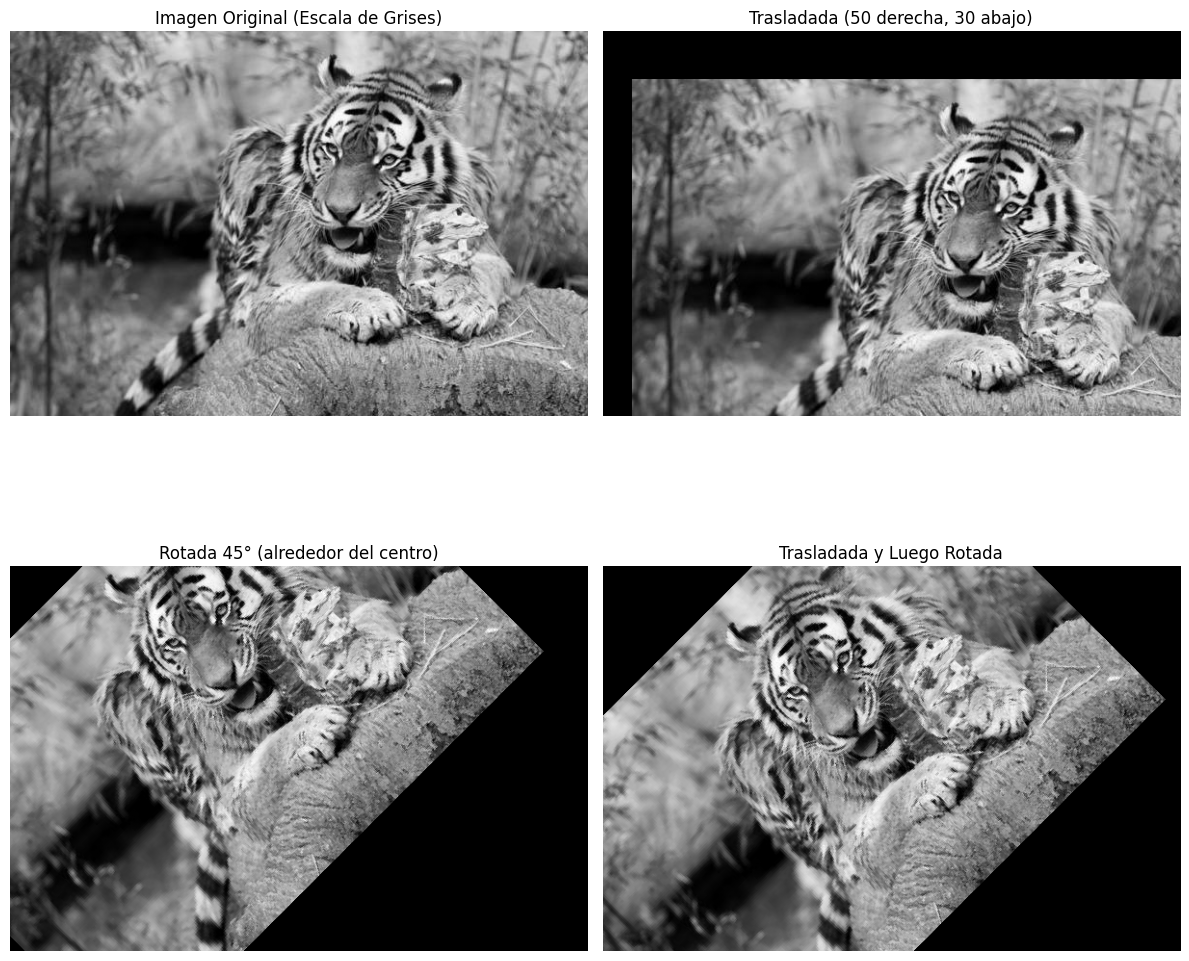

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(tigre_gray_img, cmap='gray')
axes[0, 0].set_title('Imagen Original (Escala de Grises)')
axes[0, 0].axis('off')

axes[0, 1].imshow(Y_translated, cmap='gray')
axes[0, 1].set_title('Trasladada (50 derecha, 30 abajo)')
axes[0, 1].axis('off')

axes[1, 0].imshow(Y_rotated, cmap='gray')
axes[1, 0].set_title('Rotada 45° (alrededor del centro)')
axes[1, 0].axis('off')

axes[1, 1].imshow(Y_combined, cmap='gray')
axes[1, 1].set_title('Trasladada y Luego Rotada')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

**Bibliografía**  
D. Mery. Fundamentos de Procesamiento de Imágenes Departamento de Ciencia de la Computación. Universidad Católica de Chile, 2024.